# Computing an escape time landscape

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rebound

from src.integrator.integrate import phi
from src.utils.boundary import B2_v_func

In [2]:
def number_returns_before_escape(e, v0, t0, max_ret = 100, t_max = 100):
    '''
    Returns the number of returns to z=0 (capped at max_iter)
    before the particle takes t_max or longer to return.
    '''
    i = 0
    v = v0
    t = t0

    while v is not None and i < max_ret:
        v, t = phi(e, v, t, t_max = t_max)
        i += 1
    
    if v is None:
        return i - 1
    else:
        return max_ret

Choose an eccentricity and load the boundary function

In [3]:
e = 0.5
B2_v = B2_v_func(e)

From my first experiment it seems like time to compute is approx $aN_v N_t max_{ret}$ with $a$ around 0.05
Empirical estimates of a = 23/500, 243/4500


In [29]:
N_t = 30
N_v = 30
max_ret = 5
t_max = 10

t_vals = np.linspace(0, 2*np.pi, N_t, endpoint = False)

v_max = 0
for t in t_vals:
    v_max = max(v_max, B2_v(t))

v_vals = np.linspace(0, v_max, N_v, endpoint = False)

# We prepare the grids to store the values
t_grid, v_grid = np.meshgrid(t_vals, v_vals) # Give arguments in xy ordering
ret_grid = np.zeros_like(t_grid)

# Compute loop
for i in range(N_v):
    for j in range(N_t):
        t = t_grid[i][j]
        v = v_grid[i][j]
        if v > B2_v(t):
            ret_grid[i][j] = np.nan
        else:
            ret_grid[i][j] = number_returns_before_escape(e, v, t, max_ret = max_ret, t_max = t_max)

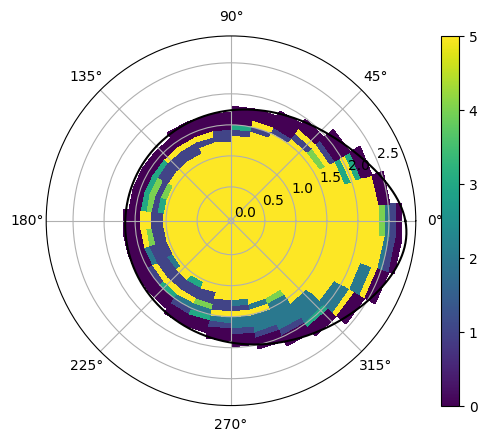

In [36]:
fig, ax = plt.subplots(subplot_kw={'projection':'polar'})
mesh = ax.pcolormesh(t_grid, v_grid, ret_grid)
cbar = fig.colorbar(mesh, ax = ax)

# Plot the boundary around it
t_bound_vals = np.linspace(0, 2*np.pi, 500)
v_bound_vals = B2_v(t_bound_vals)
ax.plot(t_bound_vals, v_bound_vals, color = 'black')

In [28]:
print(ret_grid[10:20])

[[ 5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.
   5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.]
 [ 5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.
   5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.]
 [ 5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  3.  1.  1.  1.  1.  1.  1.
   1.  1.  2.  4.  5.  5.  5.  5.  5.  5.  5.  5.]
 [ 5.  5.  5.  5.  5.  5.  5.  5.  5.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  4.  4.  5.  5.  5.  5.  5.  5.]
 [ 5.  5.  5.  5.  5.  5.  5.  5.  1.  1.  5.  5.  5.  5.  5.  5.  5.  5.
   5.  5.  1.  1.  1.  1.  4.  5.  5.  5.  5.  5.]
 [ 5.  5.  5.  5.  5.  5.  1.  1.  5.  3.  0.  0.  0.  0.  0.  0.  1.  3.
   2.  2.  2.  5.  5.  1.  4.  5.  5.  5.  5.  5.]
 [ 5.  5.  5.  5.  5.  1.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  1.  3.  2.  2.  5.  4.  2.  4.  5.  5.  5.]
 [ 5.  5.  5.  5.  5.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  1.  5.  2.  2.  2.  2.  5.  5.  5.]


In [30]:
import os

data_dir = 'data'

# Construct a descriptive filename
filename = f'escape_time_e{e}_Nt{N_t}_Nv{N_v}.npz'
filepath = os.path.join(data_dir, filename)

# Save the arrays and parameters in a compressed format
np.savez_compressed(filepath, 
                    t_grid=t_grid, 
                    v_grid=v_grid, 
                    ret_grid=ret_grid, 
                    e=e, 
                    N_t=N_t, 
                    N_v=N_v, 
                    max_ret=max_ret, 
                    t_max=t_max)

print(f"Data saved to {filepath}")

Data saved to data\escape_time_e0.5_Nt30_Nv30.npz


In [35]:
data = np.load('data/escape_time_e0.5_Nt30_Nv30.npz')
print(data.files)

['t_grid', 'v_grid', 'ret_grid', 'e', 'N_t', 'N_v', 'max_ret', 't_max']
